In [2]:
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 78.3 MB/s  0:00:00


In [3]:
!pip install seaborn --quiet

In [1]:
from sklearn.metrics import confusion_matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# metrics_df = pd.read_csv(
#     "/home/calebe/geo-projects-car/experiments/replying-unet-icmbio_128_overlap_20260419_102438/test_eval/confusion_matrix.csv",
#     index_col=0)

In [ ]:
# metrics_df = pd.read_csv(
#     "/home/calebe/geo-projects-car/experiments/replying-unet-icmbio_20260419_003116/test_eval/confusion_matrix.csv",
#     index_col=0)

In [ ]:
# metrics_df = pd.read_csv(
#     "/home/calebe/geo-projects-car/experiments/deeplabv3-resnet50-256_20260508_003335/test_eval/confusion_matrix.csv",
#     index_col=0)

In [11]:
metrics_df = pd.read_csv(
    "/home/calebe/geo-projects-car/experiments/deeplabv3-resnet50-128/test_eval/confusion_matrix.csv",
    index_col=0)

In [12]:
metrics_df

,pred_0,pred_1,pred_2,pred_3,pred_4
true_class,,,,,
true_0,24521800,4322039,9996900,609980,763996
true_1,2394516,95196220,7459448,1585658,296270
true_2,8898880,6392208,217113008,2763711,630881
true_3,1264405,4819311,15995882,5468329,54867
true_4,498389,577976,894510,8037,3924333


In [13]:
df_norm = metrics_df.div(metrics_df.sum(axis=1), axis=0)

In [14]:
class_names = [
    "Infraestrutura",
    "Agropastoril",
    "Áreas de Vegetação",
    "Macega",
    "Massa D'Água"
]

df_norm.index = class_names
df_norm.columns = class_names

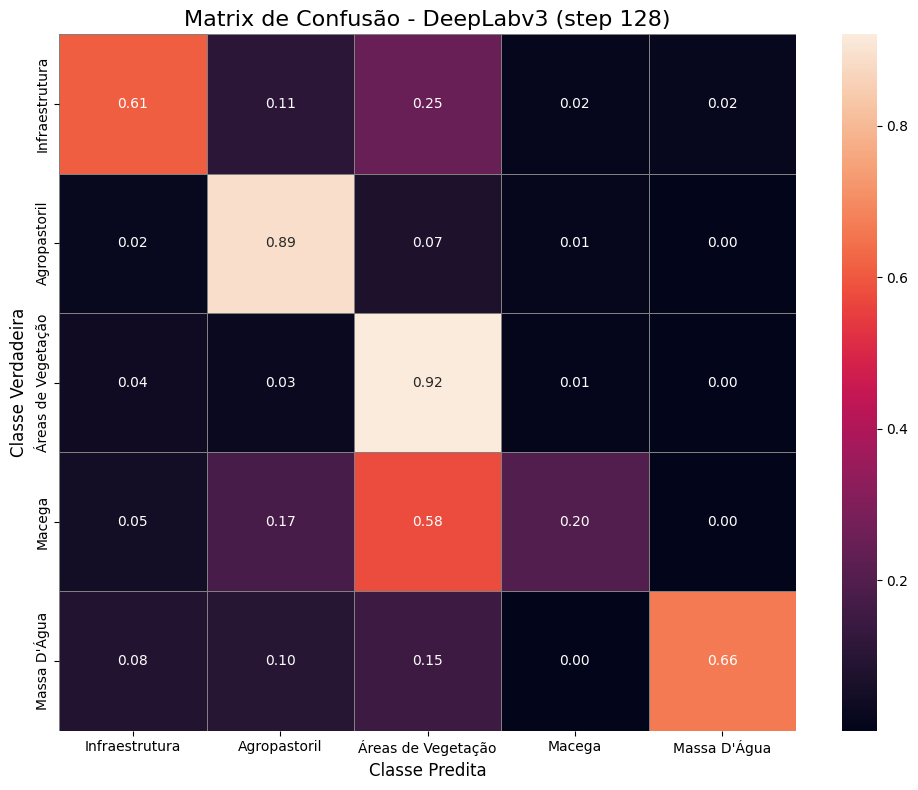

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))

sns.heatmap(
    df_norm,                     # use df para valores absolutos
    annot=True,
    fmt=".2f",                  # porcentagem
    cmap="rocket",             # ou "magma", "Blues", "rocket"
    cbar=True,
    linewidths=0.5,
    linecolor="gray"
)

plt.title("Matrix de Confusão - DeepLabv3 (step 128)", fontsize=16)
plt.xlabel("Classe Predita", fontsize=12)
plt.ylabel("Classe Verdadeira", fontsize=12)

plt.tight_layout()
plt.show()

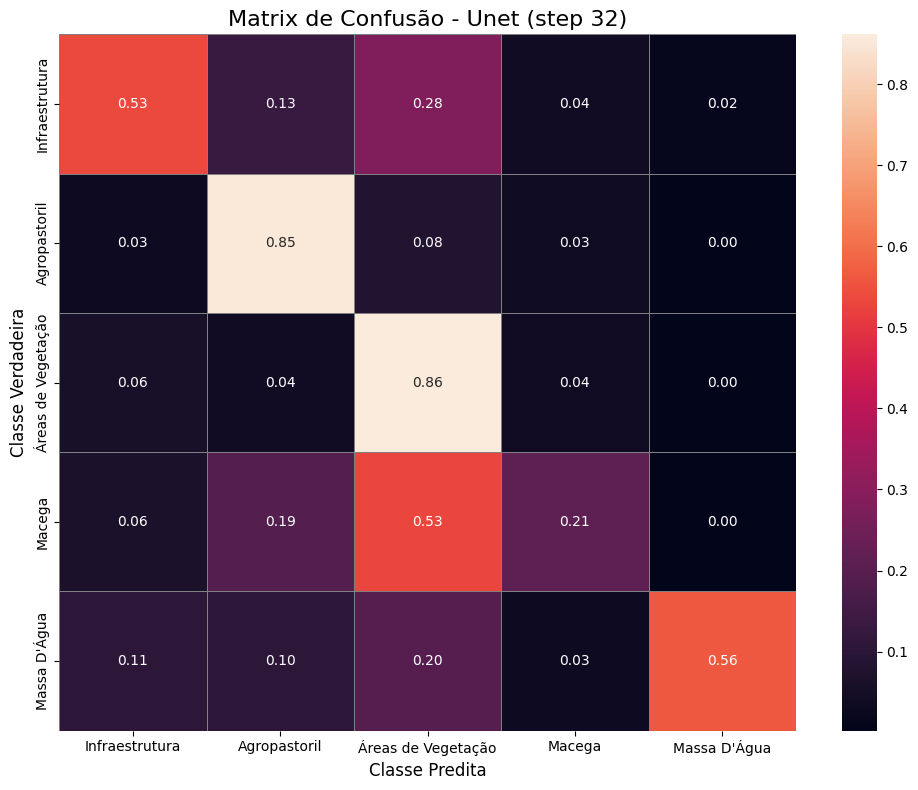

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))

sns.heatmap(
    df_norm,                     # use df para valores absolutos
    annot=True,
    fmt=".2f",                  # porcentagem
    cmap="rocket",             # ou "magma", "Blues", "rocket"
    cbar=True,
    linewidths=0.5,
    linecolor="gray"
)

plt.title("Matrix de Confusão - Unet (step 32)", fontsize=16)
plt.xlabel("Classe Predita", fontsize=12)
plt.ylabel("Classe Verdadeira", fontsize=12)

plt.tight_layout()
plt.show()

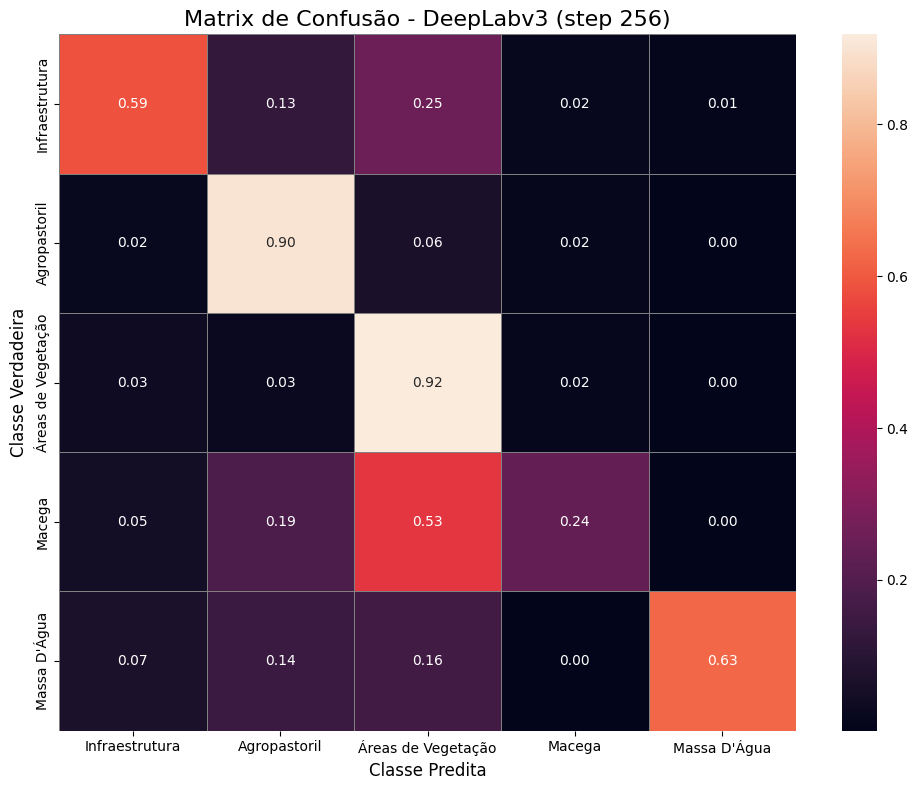

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))

sns.heatmap(
    df_norm,                     # use df para valores absolutos
    annot=True,
    fmt=".2f",                  # porcentagem
    cmap="rocket",             # ou "magma", "Blues", "rocket"
    cbar=True,
    linewidths=0.5,
    linecolor="gray"
)

plt.title("Matrix de Confusão - DeepLabv3 (step 256)", fontsize=16)
plt.xlabel("Classe Predita", fontsize=12)
plt.ylabel("Classe Verdadeira", fontsize=12)

plt.tight_layout()
plt.show()

In [16]:
from PIL import Image
import os
import numpy as np
from matplotlib.colors import ListedColormap

In [24]:
predictions_dir = "/home/calebe/geo-projects-car/experiments/replying-unet-efficientnet-128/test_eval/predictions/"
masks_dir = "/home/calebe/data/masks_replicated_full/"
satellites_dir = "/home/calebe/data/satelite_images/"
experiment_plot_path = "/home/calebe/geo-projects-car/experiments/replying-unet-efficientnet-128/test_eval/plotting_test_images/"

In [25]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

def plot_overlay_comparison(
    image_path: str,
    pred_mask,                 # np.ndarray (H,W) ou path para máscara
    gt_mask_path: str = None,  # opcional
    save_path: str = None,
    alpha: float = 0.6,
    class_colors=None,         # ex.: ['black','green'] ou ['black','red','green']
    titles=None
):
    original = Image.open(image_path).convert("RGB")

    if isinstance(pred_mask, str):
        pred = np.array(Image.open(pred_mask))
    else:
        pred = np.asarray(pred_mask)

    gt = None
    if gt_mask_path is not None:
        gt = np.array(Image.open(gt_mask_path))

    if class_colors is None:
        class_colors = ["gray", "green"]
    cmap = ListedColormap(class_colors)

    if titles is None:
        titles = {
            "gt": "Input + Ground Truth Overlay",
            "pred": "Article Based"
        }
    if gt is not None:
        fig, axes = plt.subplots(1, 2, figsize=(14, 7))
        axes[0].imshow(original)
        axes[0].imshow(gt, cmap=cmap, alpha=alpha, interpolation="none")
        axes[0].set_title(titles["gt"], fontsize=12, fontweight="bold")
        axes[0].axis("off")

        axes[1].imshow(original)
        axes[1].imshow(pred, cmap=cmap, alpha=alpha, interpolation="none")
        axes[1].set_title(titles["pred"], fontsize=12, fontweight="bold")
        axes[1].axis("off")
    else:
        fig, ax = plt.subplots(1, 1, figsize=(7, 7))
        ax.imshow(original)
        ax.imshow(pred, cmap=cmap, alpha=alpha, interpolation="none")
        ax.set_title(titles["pred"], fontsize=12, fontweight="bold")
        ax.axis("off")

    plt.tight_layout()

    if save_path is not None:
        os.makedirs(os.path.dirname(save_path) or ".", exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        plt.close(fig)
    else:
        plt.show()


In [26]:
with open("/home/calebe/geo-projects-car/experiments/replying-unet-efficientnet-128/test_eval/more_then_50.txt", 'r') as f:
    test_images = [line.strip() for line in f.readlines()]

for img_name in test_images[:101]:
    img_path = os.path.join(predictions_dir, img_name)
    original = Image.open(img_path).convert('RGB')
    gt_mask_pil = Image.open(os.path.join(masks_dir, img_name))

    cmap = ListedColormap([
    "#DC143C",  # 0 Infraestrutura
    "#FFD700",  # 1 Agropastoril
    "#006400",  # 2 Vegetação Nativa
    "#8F9779",  # 3 Macega
    "#1E90FF"  # 4 Massa D'água
    ])
        
    
    plot_overlay_comparison(
        image_path=f"{satellites_dir}{img_name}",
        pred_mask=f"{predictions_dir}{img_name}",
        # gt_mask_path="/data/integracar/amostras_car_mask_2058/ES-3204906-FEC6452DE4354398BB52137330D93B31.tif",
        gt_mask_path=f"{masks_dir}{img_name}",
        save_path=f"{experiment_plot_path}/new/overlay_{img_name}.png",
        alpha=0.6,
        class_colors=[
        "#DC143C",  # 0 Infraestrutura
        "#FFD700",  # 1 Agropastoril
        "#006400",  # 2 Vegetação Nativa
        "#8F9779",  # 3 Macega
        "#1E90FF"  # 4 Massa D'água
        ])

In [27]:
# with open("/home/calebe/geo-projects-car/data-segments/test_sample.txt", 'r') as f:
#     val_images = [line.strip() for line in f.readlines()]
    
#     # Fazer predição em algumas imagens de exemplo
#     for img_name in val_images[:31]:
#         img_path = os.path.join(predictions_dir, img_name)
                
#         # Carregar imagens
#         original = Image.open(img_path).convert('RGB')
#         gt_mask_pil = Image.open(os.path.join(masks_dir, img_name))
#         # CORRECAO: alinhar tamanhos para evitar overlay visualmente "bonito" mas deslocado.
#         if original.size != (2048, 2048):
#             original = original.resize((2048, 2048), Image.BILINEAR)
#         if gt_mask_pil.size != (2048, 2048):
#             gt_mask_pil = gt_mask_pil.resize((2048, 2048), Image.NEAREST)
#         gt_mask = np.array(gt_mask_pil)

#         pred_mask = img_path
        
#         # Criar visualização com overlays usando matplotlib
#         fig, axes = plt.subplots(1, 2, figsize=(14, 7))

#         # cmap = ListedColormap(['gray', 'green'])


#         cmap = ListedColormap([
#             "#DC143C",  # 0 Infraestrutura
#             "#FFD700",  # 1 Agropastoril
#             "#006400",  # 2 Vegetação Nativa
#             "#8F9779",  # 3 Macega
#             "#1E90FF"  # 4 Massa D'água
#         ])
        
#         # Ground Truth Overlay
#         axes[0].imshow(original)
#         axes[0].imshow(gt_mask, cmap=cmap, alpha=0.6, interpolation='none')
#         axes[0].set_title('Input + Ground Truth Overlay', fontsize=12, fontweight='bold')
#         axes[0].axis('off')
        
#         # Prediction Overlay
#         axes[1].imshow(original)
#         axes[1].imshow(pred_mask, cmap=cmap, alpha=0.6, interpolation='none')
#         axes[1].set_title('Input + Prediction Overlay', fontsize=12, fontweight='bold')
#         axes[1].axis('off')
        
#         plt.tight_layout()
#         plt.close()

In [29]:
# metrics_df.info()

In [28]:
# sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
# plt.xlabel('Predicted')
# plt.ylabel('Actual')
# plt.show()